## Aliartos Weather Extraction 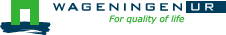


In [ ]:
import pandas as pd
import requests
from pathlib import Path

# AgERA5 API (only reachable on the WUR network / VPN)
base_url = "https://agera5.containers.wurnet.nl/"

lat, lon = 38.367, 23.167   # Aliartos, GR
try:
    test = requests.get(
        f"{base_url}api/v1/get_agera5?latitude={lat}&longitude={lon}&startdate=20200101&enddate=20200102",
        timeout=10,
    )
    test.raise_for_status()
    print("API is accessible and responsive.")
except requests.exceptions.RequestException as e:
    print(f"API access error - are you on the WUR network? Error: {e}")

API is accessible and responsive.


In [5]:
# AgERA5 -> PCSE variable mapping 
agera5_map = {
    "IRRAD": "radiation",
    "TMIN":  "temperature_min",
    "TMAX":  "temperature_max",
    "VAP":   "vapourpressure",
    "WIND":  "windspeed",
    "RAIN":  "precipitation",
}

def get_agera5(lat, lon, start, end, base_url=base_url):
    """Pull the full AgERA5 daily series for one point, formatted for PCSE."""
    resp = requests.get(
        f"{base_url}api/v1/get_agera5"
        f"?latitude={lat}&longitude={lon}&startdate={start}&enddate={end}",
        timeout=300,
    )
    resp.raise_for_status()

    agera5 = pd.DataFrame(resp.json()["weather_variables"])
    agera5.index = pd.to_datetime(agera5["day"])

    daily = pd.DataFrame(index=agera5.index)
    for col, src in agera5_map.items():
        daily[col] = agera5[src].astype(float)

    # Unit conversions to PCSE format
    daily["VAP"]   = daily["VAP"]   * 0.1     # AgERA5 hPa -> kPa
    daily["IRRAD"] = daily["IRRAD"] / 1000    # AgERA5 J/m2/day -> kJ/m2/day
    daily["SNOWDEPTH"] = -999                 # not used

    return daily

# 2012-10-01 spin-up start through 2026-01-01 (final January harvest)
daily_data = get_agera5(38.367, 23.167, "20121001", "20260101")
print(f"{len(daily_data)} days: {daily_data.index.min().date()} -> {daily_data.index.max().date()}")
daily_data = daily_data.sort_index()
daily_data.tail()

4840 days: 2012-10-01 -> 2025-12-31


,IRRAD,TMIN,TMAX,VAP,WIND,RAIN,SNOWDEPTH
day,,,,,,,
2025-12-27,5503.427,4.518823,10.840265,0.868420,1.828637,0.11,-999
2025-12-28,9957.917,1.616144,14.677881,0.759400,1.499976,0.00,-999
2025-12-29,9333.991,2.566614,12.643335,0.729005,1.196465,0.00,-999
2025-12-30,8314.137,3.331750,14.505610,0.868852,1.678533,0.86,-999
2025-12-31,3178.099,3.432458,8.337427,0.656742,2.552853,5.04,-999


In [ ]:
import openpyxl

xlsx_path = Path.cwd() / "aliartos_weather.xlsx"

wb = openpyxl.load_workbook(xlsx_path)
ws = wb["observed_daily_weather"]

for i, (date, row) in enumerate(daily_data.iterrows()):
    r = i + 13
    ws.cell(row=r, column=1, value=date.to_pydatetime())
    ws.cell(row=r, column=2, value=row["IRRAD"])
    ws.cell(row=r, column=3, value=row["TMIN"])
    ws.cell(row=r, column=4, value=row["TMAX"])
    ws.cell(row=r, column=5, value=row["VAP"])
    ws.cell(row=r, column=6, value=row["WIND"])
    ws.cell(row=r, column=7, value=row["RAIN"])
    ws.cell(row=r, column=8, value=row["SNOWDEPTH"])

wb.save(xlsx_path)
print(f"Written {len(daily_data)} rows to {xlsx_path}")

Written 4840 rows to /Users/paulianoprescu/Projects/wofost_miscanthus/giganteus/calibration/weather/aliartos_weather.xlsx
